# Load DATA

In [ ]:
# from sklearn.datasets import fetch_openml
# boston=fetch_openml(name='Boston',version=1,as_frame=True)
# data=boston.frame
# data.head()

In [33]:
import numpy as np
import pandas as pd

In [35]:
df=pd.read_csv('HousingData.csv')

In [37]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [42]:
X=df.drop(['MEDV'],axis=1)
y=df['MEDV']

# Single Linear Regression

In [66]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X_rm=X[['RM']]
X_rm_train,X_rm_test,y_train,y_test=train_test_split(X_rm,y,test_size=0.2,random_state=42)

sl_m=LinearRegression()
sl_m.fit(X_rm_train,y_train)
y_rm=sl_m.predict(X_rm_test)

In [71]:
from sklearn.metrics import mean_squared_error, r2_score
print("R2 Score:", r2_score(y_test,y_rm))
print("MSE:", mean_squared_error(y_test, y_rm))



R2 Score: 0.3707569232254778
MSE: 46.144775347317264


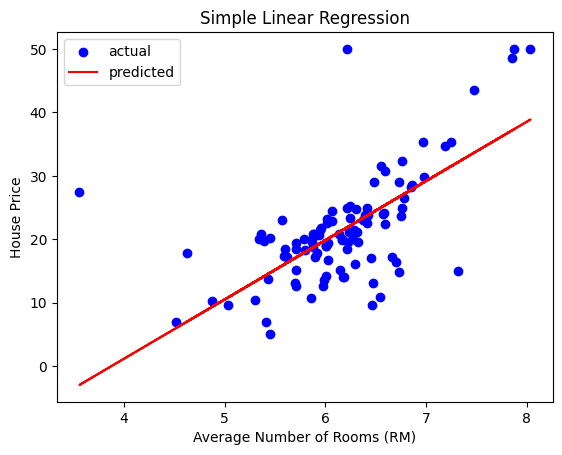

In [87]:
# Plot
import matplotlib.pyplot as plt

plt.scatter(X_rm_test, y_test, color='blue',label='actual')
plt.plot(X_rm_test, y_rm, color='red',label='predicted')
plt.xlabel('Average Number of Rooms (RM)')
plt.ylabel('House Price')
plt.title('Simple Linear Regression')
plt.legend()
plt.show()

# Multiple Linear Regression

In [103]:
X

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48


In [109]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [111]:
model=LinearRegression()
model.fit(X_train_scaled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [115]:
y_prd=model.predict(X_test_scaled)

In [117]:
from sklearn.metrics import mean_squared_error, r2_score
print("R2 Score:", r2_score(y_test,y_prd))
print("MSE:", mean_squared_error(y_test, y_prd))



R2 Score: 0.668759493535632
MSE: 24.291119474973513


In [153]:
coefficients=pd.DataFrame({
    'features':X.columns,
    'weight':model.coef_
})
print(coefficients)

   features    weight
0      CRIM -1.002135
1        ZN  0.696269
2     INDUS  0.278065
3      CHAS  0.718738
4       NOX -2.022319
5        RM  3.145240
6       AGE -0.176048
7       DIS -3.081908
8       RAD  2.251407
9       TAX -1.767014
10  PTRATIO -2.037752
11        B  1.129568
12    LSTAT -3.611658


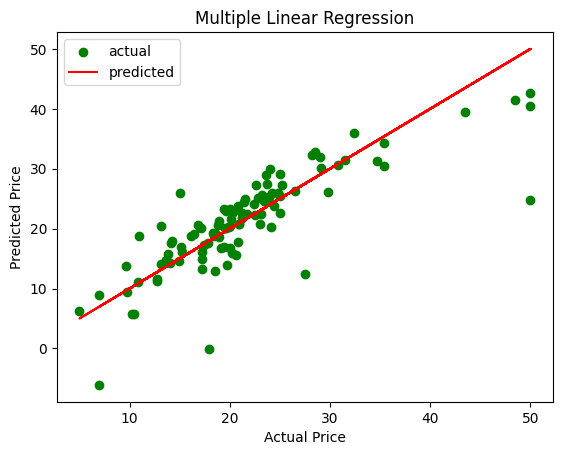

In [196]:
# Plot
import matplotlib.pyplot as plt

plt.scatter(y_test,y_pred, color='green',label='actual')
plt.plot(y_test,y_test, color='red',label='predicted')
# plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Multiple Linear Regression')
plt.legend()
plt.show()

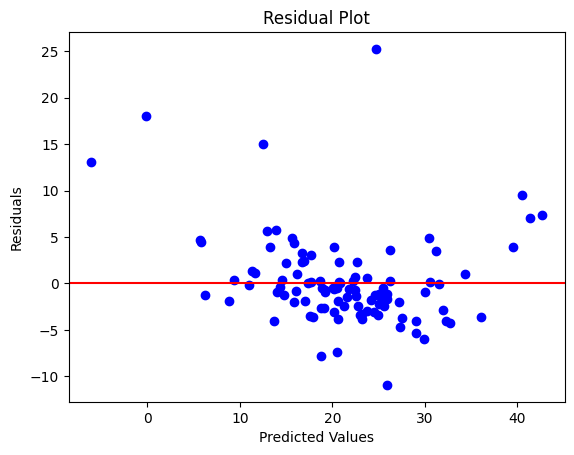

In [157]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals,c='blue')
plt.axhline(y=0, color='red')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

# Polynomial Regression

In [204]:
from sklearn.preprocessing import PolynomialFeatures

poly=PolynomialFeatures(degree=2)
X_train_poly=poly.fit_transform(X_train_scaled)
X_test_poly=poly.transform(X_test_scaled)

poly_lr=LinearRegression()
poly_lr.fit(X_train_poly,y_train)
y_pred_poly=poly_lr.predict(X_test_poly)


In [206]:
from sklearn.metrics import mean_squared_error, r2_score
print("R2 Score:", r2_score(y_test,y_pred_poly))
print("MSE:", mean_squared_error(y_test, y_pred_poly))

R2 Score: 0.8055829447972156
MSE: 14.257338168909532


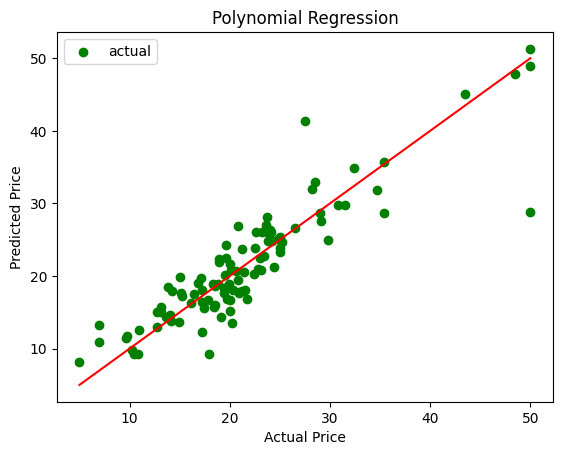

In [208]:
# Plot
import matplotlib.pyplot as plt

plt.scatter(y_test,y_pred_poly, color='green',label='actual')
# plt.plot(y_test,y_test, color='red',label='predicted')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Polynomial Regression')
plt.legend()
plt.show()

# Rigde Regression

In [230]:
from sklearn.linear_model import Ridge
ridge=Ridge(alpha=1.0)
ridge.fit(X_train_scaled,y_train)
y_pred_rig=ridge.predict(X_test_scaled)

In [232]:
from sklearn.metrics import mean_squared_error, r2_score
print("R2 Score:", r2_score(y_test,y_pred_rig))
print("MSE:", mean_squared_error(y_test, y_pred_rig))

R2 Score: 0.6684624359643558
MSE: 24.312903830491614


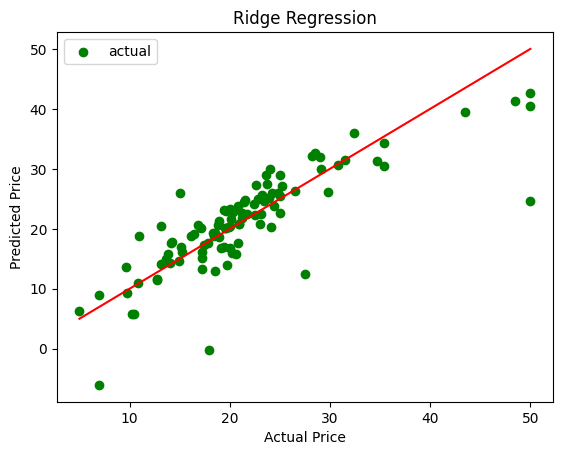

In [234]:
# Plot
import matplotlib.pyplot as plt

plt.scatter(y_test,y_pred_rig, color='green',label='actual')
# plt.plot(y_test,y_test, color='red',label='predicted')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Ridge Regression')
plt.legend()
plt.show()

In [240]:
for a in [0.01, 0.1, 1, 10, 100]:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train)
    y_pred = ridge.predict(X_test_scaled)
    
    print(f"Alpha: {a}")
    print("R2:", r2_score(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("--------")

Alpha: 0.01
R2: 0.6687565288011175
MSE: 24.29133689017153
--------
Alpha: 0.1
R2: 0.668729836880831
MSE: 24.293294309665953
--------
Alpha: 1
R2: 0.6684624359643558
MSE: 24.312903830491614
--------
Alpha: 10
R2: 0.6659677905050341
MSE: 24.495845619667406
--------
Alpha: 100
R2: 0.6546262113936663
MSE: 25.327566522916094
--------


# Regularized Polynomial Regression

In [247]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

# Polynomial features
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# Ridge on polynomial features
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_poly, y_train)

y_pred = ridge.predict(X_test_poly)

print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.8162948990229996
MSE: 13.471790040492586


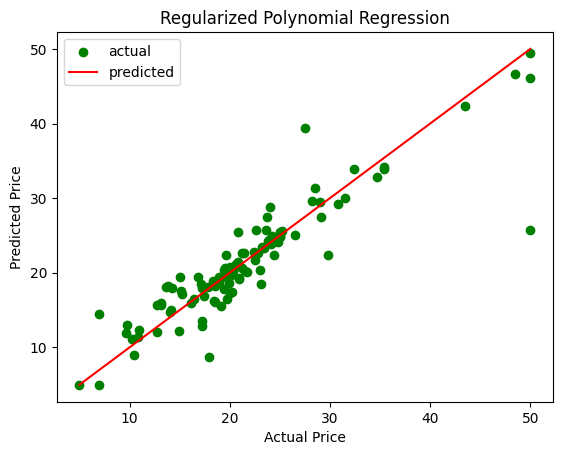

In [299]:
# Plot
import matplotlib.pyplot as plt

plt.scatter(y_test,y_pred, color='green',label='actual')
# plt.plot(y_test,y_test, color='red',label='predicted')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red',label='predicted')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Regularized Polynomial Regression')
plt.legend()
plt.show()

# Lasso Regression

In [276]:
from sklearn.linear_model import Lasso
laso=Lasso(alpha=0.1)
laso.fit(X_train_scaled,y_train)
y_pred_las=laso.predict(X_test_sclaed)

In [278]:
from sklearn.metrics import mean_squared_error, r2_score
print("R2 Score:", r2_score(y_test,y_pred_las))
print("MSE:", mean_squared_error(y_test, y_pred_las))

R2 Score: 0.6501375183238987
MSE: 25.656739367167678


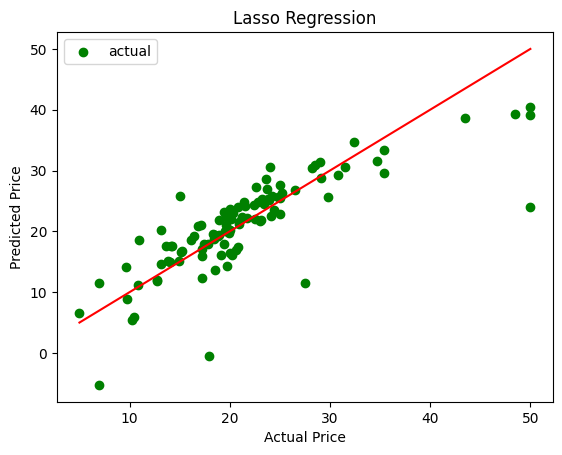

In [301]:
# Plot
import matplotlib.pyplot as plt

plt.scatter(y_test,y_pred_las, color='green',label='actual')
# plt.plot(y_test,y_test, color='red',label='predicted')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Lasso Regression')
plt.legend()
plt.show()

In [281]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Weight": laso.coef_
})

print(coefficients)

    Feature    Weight
0      CRIM -0.718365
1        ZN  0.259627
2     INDUS -0.000000
3      CHAS  0.698221
4       NOX -1.568142
5        RM  3.271507
6       AGE -0.000000
7       DIS -2.284449
8       RAD  0.671938
9       TAX -0.356654
10  PTRATIO -1.893335
11        B  1.031366
12    LSTAT -3.609410


In [284]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

lasso = Lasso(alpha=0.1)
lasso.fit(X_train_poly, y_train)

y_pred = lasso.predict(X_test_poly)

print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.8122168137984364
MSE: 13.77085145806002


# ElasticNet Rgression

In [289]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic.fit(X_train_scaled, y_train)
y_pred_elastic = elastic.predict(X_test_scaled)

print("ElasticNet Regression R2:", r2_score(y_test, y_pred_elastic))
print("MSE:", mean_squared_error(y_test, y_pred_elastic))

ElasticNet Regression R2: 0.6563172951034018
MSE: 25.203552956840404


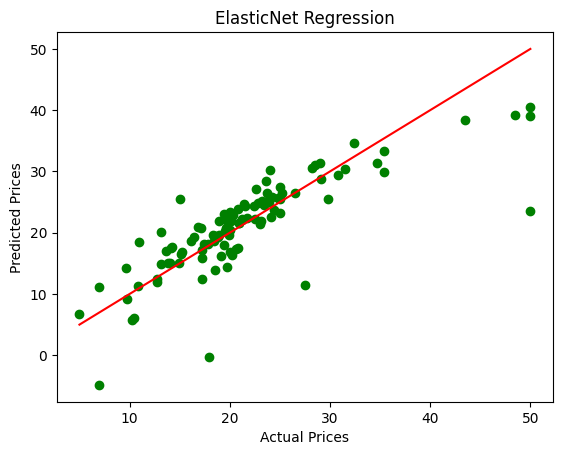

In [293]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_elastic,c='green')

plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red')

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("ElasticNet Regression")

plt.show()

In [295]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Weight": elastic.coef_
})

print(coefficients)

print("Zero Coefficients:", sum(elastic.coef_ == 0))

    Feature    Weight
0      CRIM -0.761221
1        ZN  0.322227
2     INDUS -0.031008
3      CHAS  0.736913
4       NOX -1.395953
5        RM  3.233606
6       AGE -0.096111
7       DIS -2.175919
8       RAD  0.846537
9       TAX -0.623952
10  PTRATIO -1.830041
11        B  1.040336
12    LSTAT -3.403830
Zero Coefficients: 0


In [297]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic.fit(X_train_poly, y_train)

y_pred = elastic.predict(X_test_poly)

print("R2:", r2_score(y_test, y_pred))

R2: 0.819150948936102
